# Ausgrid experiment 2, revised: paired conditional diffusion

This is a **follow-on to `Ausgrid_Colab.ipynb`**. Keep that notebook and its completed VAE runs. The first diffusion run produced implausible thousands-of-kWh peaks. This revision uses new names (`diffusion_v2` and `diffusion_v2_post`), so the failed results remain available for diagnosis and cannot be mixed with the revised experiment. Put this notebook in the same `notebooks/` directory. It reads `data/prepared/prepared.npz`, uses the **same split and conditions**, and writes new checkpoints, samples, and reports under `outputs/`. The unmasked and post-masked arms reuse the *same generated profiles*.

Run it in VS Code with a GPU Python kernel (including a Colab kernel if desired). It locates the project from the notebook folder and reads the prepared data from the local `data/` folder; no Drive mounting or zip upload is needed. The model generates **independent paired days**, not continuous synthetic households. The household membership AUC is a bounded empirical probe, not a privacy guarantee.

Motivation: [Fu et al. (2024)](https://arxiv.org/abs/2404.00525) studied conditional diffusion for energy meter synthesis. This Ausgrid comparison is a separate experiment with less metadata and a different target.


In [4]:
from pathlib import Path
import os, sys, json, math, random, time, hashlib, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

workdir = Path.cwd().resolve()
candidates = [workdir, workdir.parent, workdir/'ausgrid-synthetic',
              Path('/content/drive/MyDrive/ausgrid-synthetic')]
PROJECT_ROOT = next((p for p in candidates if (p/'data/prepared/prepared.npz').is_file()
                     and (p/'src/ausgrid_synth/evaluate.py').is_file()), None)
if PROJECT_ROOT is None:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic')
assert (PROJECT_ROOT / 'src/ausgrid_synth/evaluate.py').is_file(), 'Use the project from the original Colab notebook.'
assert (PROJECT_ROOT / 'data/prepared/prepared.npz').is_file(), 'Run the original notebook through Checkpoint 1 first.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from ausgrid_synth.data import load_prepared
from ausgrid_synth import evaluate as existing_evaluation

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type == 'cuda', 'Use a Colab GPU runtime for diffusion training and sampling.'
DATA = load_prepared(PROJECT_ROOT / 'data/prepared/prepared.npz')
assert DATA['x'].ndim == 3 and DATA['x'].shape[1:] == (2,48)
assert sorted(np.unique(DATA['split']).tolist()) == [0,1,2]
print('GPU:', torch.cuda.get_device_name(0))
print('Paired days:', len(DATA['x']), '| Household split:',
      {name: len(np.unique(DATA['customer'][DATA['split']==code])) for code,name in enumerate(('train','val','test'))})

# Fingerprint the prepared input to prevent resuming against changed data.
hash_obj = hashlib.sha256()
with (PROJECT_ROOT/'data/prepared/prepared.npz').open('rb') as f:
    for block in iter(lambda: f.read(4*1024*1024), b''):
        hash_obj.update(block)
DATA_SHA256 = hash_obj.hexdigest()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
Paired days: 325482 | Household split: {'train': 180, 'val': 60, 'test': 60}


## Fixed experiment settings

Both channels are learned **jointly** as 96 values. Apply `log1p(interval kWh / training channel scale)`, then standardize each channel using **training households only**. The revised model predicts velocity (v), avoiding division by a nearly zero signal term when reconstructing a clean sample. Use a cosine schedule with zero terminal signal and 50 deterministic DDIM sampling steps. The choice of output clipping must never make an unstable sampler look good: fail on nonfinite or extreme values before full evaluation. Diffusion and VAE share calendar/capacity inputs, household split, matched sample contexts, and evaluation code. The only difference between `diffusion_v2` and `diffusion_v2_post` is the final night mask.

**Primary comparisons:** load/solar daily W1, upper-tail peak errors, morning-to-afternoon real-test MAE. Report nighttime GG and household attack AUC alongside them. Three seeds capture training variability; the held-out households are still a single fixed split.


In [5]:
CFG = dict(timesteps=200, ddim_steps=50, hidden=256, depth=3, batch_size=512,
           learning_rate=1e-3, patience=5, epochs=25, transform='log1p_energy_by_training_scale',
           prediction='velocity', model_version=2)
train_log = np.log1p(DATA['x'][DATA['split']==0] / DATA['scale'][None,:,None])
TRAIN_MEAN = train_log.mean(axis=(0,2),keepdims=True).astype('float32')
TRAIN_STD = np.maximum(train_log.std(axis=(0,2),keepdims=True),1e-3).astype('float32')
CFG['transform'] = 'log1p_then_train_channel_standardization'
CFG['train_mean'] = TRAIN_MEAN.reshape(-1).tolist()
CFG['train_std'] = TRAIN_STD.reshape(-1).tolist()
del train_log
SEEDS = (1, 2, 3)
ARM = 'diffusion_v2'
MASKED_ARM = 'diffusion_v2_post'
MODEL_DIR = PROJECT_ROOT/'outputs/checkpoints'
SAMPLE_DIR = PROJECT_ROOT/'outputs/samples'
REPORT_DIR = PROJECT_ROOT/'outputs/reports'
for path in (MODEL_DIR, SAMPLE_DIR, REPORT_DIR): path.mkdir(parents=True, exist_ok=True)
print('Settings:', CFG)


Settings: {'timesteps': 200, 'ddim_steps': 50, 'hidden': 256, 'depth': 3, 'batch_size': 512, 'learning_rate': 0.001, 'patience': 5, 'epochs': 25, 'transform': 'log1p_then_train_channel_standardization', 'prediction': 'velocity', 'model_version': 2, 'train_mean': [0.22285740077495575, 0.15302108228206635], 'train_std': [0.21523265540599823, 0.2570474445819855]}


## Model and cosine schedule

The denoiser takes a noisy 96-value paired day, the same four standardized conditions as the VAE, and a sinusoidal time embedding. It predicts velocity at a randomly selected diffusion step. Its output is unconstrained during training; nonnegativity and nighttime zero are applied to generated profiles after sampling. The capacity rating is a condition, **not** a strict energy cap.


In [6]:
def time_embedding(t, dimension=32):
    half = dimension // 2
    frequencies = torch.exp(-math.log(10000) * torch.arange(half, device=t.device, dtype=torch.float32) / (half - 1))
    angle = t.float()[:, None] * frequencies[None, :]
    return torch.cat((angle.sin(), angle.cos()), dim=1)

class PairedDenoiser(nn.Module):
    def __init__(self, hidden=256, depth=3, timesteps=200):
        super().__init__()
        self.timesteps = timesteps
        grid = torch.linspace(0, timesteps, timesteps + 1, dtype=torch.float64)
        signal = torch.cos(((grid / timesteps + .008) / 1.008) * math.pi / 2)
        signal = (signal - signal[-1]) / (signal[0] - signal[-1])
        self.register_buffer('alpha_bar', signal[1:].square().float())
        self.time_net = nn.Sequential(nn.Linear(32, hidden), nn.SiLU(), nn.Linear(hidden, hidden))
        self.input_net = nn.Linear(96 + 4 + hidden, hidden)
        self.blocks = nn.ModuleList([nn.Sequential(nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, hidden))
                                     for _ in range(depth)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(depth)])
        self.output_net = nn.Linear(hidden, 96)

    def forward(self, x, t, cond):
        emb = self.time_net(time_embedding(t))
        h = F.silu(self.input_net(torch.cat((x, cond, emb), dim=1)))
        for block, norm in zip(self.blocks, self.norms):
            h = norm(h + block(h))
        return self.output_net(F.silu(h))

    def loss(self, x0, cond, generator=None):
        t = torch.randint(0, self.timesteps, (len(x0),), device=x0.device, generator=generator)
        eps = torch.randn(x0.shape, device=x0.device, generator=generator)
        abar = self.alpha_bar[t, None]
        xt = abar.sqrt() * x0 + (1 - abar).sqrt() * eps
        velocity = abar.sqrt() * eps - (1 - abar).sqrt() * x0
        return F.mse_loss(self(xt, t, cond), velocity)

assert PairedDenoiser(timesteps=CFG['timesteps']).alpha_bar[-1].item() == 0
print('Final signal fraction:', PairedDenoiser(timesteps=CFG['timesteps']).alpha_bar[-1].item())

# An algebra check that includes the zero-signal terminal step.
for a in (0., .1, .9, 1.):
    x0, noise = 1.25, -.75
    xt = math.sqrt(a)*x0 + math.sqrt(1-a)*noise
    velocity = math.sqrt(a)*noise - math.sqrt(1-a)*x0
    assert abs(math.sqrt(a)*xt - math.sqrt(1-a)*velocity - x0) < 1e-6


Final signal fraction: 0.0


## Checkpoint 1 — short pilot, then full training

This training function writes `diffusion_v2_seedN_latest.pt` **at the end of each epoch** and keeps the best-validation `diffusion_v2_seedN.pt`. The latest file contains optimizer and random states; rerunning continues at the next epoch. The status file records progress. The two-epoch pilot is continued by the 25-epoch run without restarting. If you change `CFG` or prepared data, choose a new arm name for a new experiment.


In [7]:
def transformed_dataset(code):
    selected = DATA['split'] == code
    log_energy = np.log1p(DATA['x'][selected] / DATA['scale'][None,:,None])
    x = ((log_energy - TRAIN_MEAN) / TRAIN_STD).reshape(-1,96).astype('float32')
    c = DATA['cond'][selected].astype('float32')
    return TensorDataset(torch.from_numpy(x), torch.from_numpy(c))

def safe_save_torch(obj, path):
    tmp = path.with_suffix('.tmp')
    torch.save(obj, tmp)
    tmp.replace(path)

def fit_diffusion(seed, epochs):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    model = PairedDenoiser(CFG['hidden'], CFG['depth'], CFG['timesteps']).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['learning_rate'])
    loader_rng = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(transformed_dataset(0), batch_size=CFG['batch_size'], shuffle=True,
                              generator=loader_rng, pin_memory=True, num_workers=0)
    val_loader = DataLoader(transformed_dataset(1), batch_size=CFG['batch_size'], shuffle=False,
                            pin_memory=True, num_workers=0)
    best_path = MODEL_DIR/f'{ARM}_seed{seed}.pt'
    latest_path = MODEL_DIR/f'{ARM}_seed{seed}_latest.pt'
    status_path = MODEL_DIR/f'{ARM}_seed{seed}_status.json'
    start, best, stale = 0, float('inf'), 0
    if latest_path.exists():
        state = torch.load(latest_path, map_location='cpu', weights_only=False)  # own trusted checkpoint
        if state['config'] != CFG or state['data_sha256'] != DATA_SHA256 or state['seed'] != seed:
            raise ValueError('Existing diffusion checkpoint uses different settings or prepared data.')
        model.load_state_dict(state['model']); optimizer.load_state_dict(state['optimizer'])
        for slot in optimizer.state.values():
            for name, value in slot.items():
                if isinstance(value, torch.Tensor) and name != 'step': slot[name] = value.to(DEVICE)
        start, best, stale = state['epoch'] + 1, state['best'], state['stale']
        random.setstate(state['python_rng']); np.random.set_state(state['numpy_rng'])
        torch.set_rng_state(state['torch_rng']); torch.cuda.set_rng_state_all(state['cuda_rng'])
        loader_rng.set_state(state['loader_rng'])
        print('Resuming seed', seed, 'at epoch', start + 1)
    if start >= epochs:
        print('Seed', seed, 'has already completed', start, 'epochs.'); return
    for epoch in range(start, epochs):
        model.train(); training_sum=0.0; training_n=0
        for x, cond in train_loader:
            x, cond = x.to(DEVICE, non_blocking=True), cond.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = model.loss(x, cond)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            training_sum += loss.item()*len(x); training_n += len(x)
        model.eval(); validation_sum=0.0; validation_n=0
        val_rng = torch.Generator(device=DEVICE).manual_seed(930001)  # fixed validation noise every epoch
        with torch.no_grad():
            for x, cond in val_loader:
                x, cond = x.to(DEVICE, non_blocking=True), cond.to(DEVICE, non_blocking=True)
                loss = model.loss(x, cond, generator=val_rng)
                validation_sum += loss.item()*len(x); validation_n += len(x)
        validation_loss = validation_sum/validation_n
        if validation_loss < best - 1e-5:
            best, stale = validation_loss, 0
            safe_save_torch({'model': model.state_dict(), 'config': CFG, 'seed': seed,
                             'data_sha256': DATA_SHA256, 'best_validation': best}, best_path)
        else: stale += 1
        latest = {'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'config': CFG,
                  'data_sha256': DATA_SHA256, 'seed': seed, 'epoch': epoch, 'best': best, 'stale': stale,
                  'python_rng': random.getstate(), 'numpy_rng': np.random.get_state(),
                  'torch_rng': torch.get_rng_state(), 'cuda_rng': torch.cuda.get_rng_state_all(),
                  'loader_rng': loader_rng.get_state()}
        safe_save_torch(latest, latest_path)
        status = {'seed': seed, 'last_epoch': epoch+1, 'target_epochs': epochs, 'early_stopped': stale >= CFG['patience'],
                  'best_validation': best, 'data_sha256': DATA_SHA256, 'config': CFG}
        status_path.with_suffix('.tmp').write_text(json.dumps(status,indent=2))
        status_path.with_suffix('.tmp').replace(status_path)
        print(f"seed={seed} epoch={epoch+1} train={training_sum/training_n:.5f} val={validation_loss:.5f} best={best:.5f}", flush=True)
        if stale >= CFG['patience']: break

pilot_start = time.time()
for seed in (1,):
    status_path = MODEL_DIR/f'{ARM}_seed{seed}_status.json'
    if not status_path.exists(): fit_diffusion(seed, epochs=2)
print('Pilot elapsed minutes:', round((time.time()-pilot_start)/60,1))


seed=1 epoch=1 train=0.58399 val=0.50876 best=0.50876
seed=1 epoch=2 train=0.49852 val=0.47765 best=0.47765
Pilot elapsed minutes: 0.2


### Full seed 1 training

After the pilot, inspect its runtime. The default run continues seed 1, then checks generated samples on validation households **before** training seeds 2 and 3 or touching the held-out test. Re-executing this cell skips a finished seed.


In [8]:
for seed in (1,):
    status_path = MODEL_DIR/f'{ARM}_seed{seed}_status.json'
    status = json.loads(status_path.read_text()) if status_path.exists() else {}
    complete = (status.get('target_epochs') == CFG['epochs'] and
                (status.get('early_stopped') or status.get('last_epoch',0) >= CFG['epochs']))
    if complete and status.get('config') == CFG and status.get('data_sha256') == DATA_SHA256:
        print('Already finished seed', seed)
    else:
        fit_diffusion(seed, CFG['epochs'])


Resuming seed 1 at epoch 3
seed=1 epoch=3 train=0.47464 val=0.45913 best=0.45913
seed=1 epoch=4 train=0.45663 val=0.44420 best=0.44420
seed=1 epoch=5 train=0.44586 val=0.43534 best=0.43534
seed=1 epoch=6 train=0.43758 val=0.42887 best=0.42887
seed=1 epoch=7 train=0.43200 val=0.42425 best=0.42425
seed=1 epoch=8 train=0.42822 val=0.42045 best=0.42045
seed=1 epoch=9 train=0.42459 val=0.41751 best=0.41751
seed=1 epoch=10 train=0.42084 val=0.41549 best=0.41549
seed=1 epoch=11 train=0.41909 val=0.41370 best=0.41370
seed=1 epoch=12 train=0.41753 val=0.41307 best=0.41307
seed=1 epoch=13 train=0.41573 val=0.41087 best=0.41087
seed=1 epoch=14 train=0.41347 val=0.40948 best=0.40948
seed=1 epoch=15 train=0.41265 val=0.41035 best=0.40948
seed=1 epoch=16 train=0.41200 val=0.40862 best=0.40862
seed=1 epoch=17 train=0.41081 val=0.40758 best=0.40758
seed=1 epoch=18 train=0.41036 val=0.40788 best=0.40758
seed=1 epoch=19 train=0.40918 val=0.40560 best=0.40560
seed=1 epoch=20 train=0.40817 val=0.40602 bes

## Checkpoint 2 — matched sampling

For fair comparison, recreate the exact three context index sets used by the original CLI: 30,000 training days, all held-out days, and 8,000 shared contexts for the attack. Confirm indices against a previous `vae_post` sample when present. DDIM uses 50 deterministic reverse steps after the initial seeded Gaussian noise. First run a **validation-household peak gate** on seed 1; this stops before full sampling if extreme output recurs. Then train seeds 2 and 3 and save each sample twice, before and after masking, with identical internal indices. These files are for **local evaluation only** because their `idx` links to household data in the prepared file.


In [9]:
def context_indices(context):
    rng = np.random.default_rng(2026)
    if context == 'train':
        available = np.flatnonzero(DATA['split'] == 0)
        return rng.choice(available, size=min(30000,len(available)), replace=False)
    if context == 'test': return np.flatnonzero(DATA['split'] == 2)
    if context == 'privacy':
        available = np.flatnonzero(np.isin(DATA['split'],[0,2]))
        return rng.choice(available, size=min(8000,len(available)), replace=False)
    raise ValueError(context)

for context in ('train','test','privacy'):
    reference_path = SAMPLE_DIR/f'vae_post_seed1_{context}.npz'
    if reference_path.exists():
        with np.load(reference_path, allow_pickle=False) as reference:
            assert np.array_equal(context_indices(context),reference['idx']), f'Context differs from VAE: {context}'
    print(context, len(context_indices(context)), 'contexts')

@torch.inference_mode()
def generate_diffusion(seed, indices, batch_size=2048):
    best_path = MODEL_DIR/f'{ARM}_seed{seed}.pt'
    checkpoint = torch.load(best_path, map_location='cpu', weights_only=False)  # own trusted checkpoint
    if checkpoint['data_sha256'] != DATA_SHA256 or checkpoint['config'] != CFG:
        raise ValueError('Diffusion model does not match this dataset/configuration.')
    model = PairedDenoiser(CFG['hidden'], CFG['depth'], CFG['timesteps']).to(DEVICE)
    model.load_state_dict(checkpoint['model']); model.eval()
    steps = np.rint(np.linspace(CFG['timesteps']-1, 0, CFG['ddim_steps'])).astype(int)
    assert len(np.unique(steps)) == len(steps) and steps[-1] == 0
    generator = torch.Generator(device=DEVICE).manual_seed(2026+seed)
    batches=[]
    for batch_no, start in enumerate(range(0,len(indices),batch_size)):
        chunk = indices[start:start+batch_size]
        cond = torch.from_numpy(DATA['cond'][chunk].astype('float32')).to(DEVICE)
        x = torch.randn((len(chunk),96),device=DEVICE,generator=generator)
        for j,step in enumerate(steps):
            current = torch.full((len(chunk),),int(step),device=DEVICE,dtype=torch.long)
            velocity = model(x,current,cond)
            a = model.alpha_bar[int(step)]
            clean = a.sqrt()*x - (1-a).sqrt()*velocity
            eps = (1-a).sqrt()*x + a.sqrt()*velocity
            if j+1 < len(steps):
                next_a = model.alpha_bar[int(steps[j+1])]
                x = next_a.sqrt()*clean + (1-next_a).sqrt()*eps  # DDIM, eta=0
            else: x = clean
            if not torch.isfinite(x).all(): raise ValueError('Nonfinite diffusion sample; stop before evaluation.')
        batches.append(x.reshape(-1,2,48).cpu().numpy())
        if batch_no % 20 == 0: print('generated',min(start+batch_size,len(indices)),'/',len(indices),flush=True)
    model.cpu(); del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    latent = np.concatenate(batches)
    if not np.isfinite(latent).all(): raise ValueError('Nonfinite diffusion output; inspect training.')
    log_energy = latent * TRAIN_STD + TRAIN_MEAN
    if np.max(log_energy) > 8:
        raise ValueError('Extreme generated log energy; stop before exponentiation/evaluation.')
    # Nonnegative energy is the inverse-transform domain constraint; no upper clip hides peaks.
    energy = np.expm1(np.maximum(log_energy,0)) * DATA['scale'][None,:,None]
    ceiling = 10 * np.max(DATA['x'][DATA['split']==0],axis=(0,2))
    if not np.isfinite(energy).all() or (np.max(energy,axis=(0,2)) > ceiling).any():
        raise ValueError('Extreme generated interval energy; stop before saving/evaluation.')
    return energy.astype('float32')

def write_sample(path, x, idx):
    path.parent.mkdir(parents=True,exist_ok=True)
    tmp=path.with_suffix('.tmp')
    with tmp.open('wb') as f: np.savez_compressed(f,x=x,idx=idx)
    tmp.replace(path)


train 30000 contexts
test 65203 contexts
privacy 8000 contexts


### Validation peak gate

Generate a small sample using **validation households**. If its 95th-percentile interval peak exceeds three times the matched real peak (or an individual interval exceeds ten times the training maximum), stop here. The held-out test set is untouched. The threshold catches the thousands-of-kWh failure observed in the first diffusion run; passing it does not establish overall model quality.


In [10]:
VALIDATION_GATE_PASSED = False

val_indices = np.flatnonzero(DATA['split'] == 1)
probe_idx = np.random.default_rng(2026).choice(val_indices,size=min(2048,len(val_indices)),replace=False)
probe = generate_diffusion(1,probe_idx,batch_size=512)
for channel,label in enumerate(('GC+CL','GG')):
    observed_peak = DATA['x'][probe_idx,channel].max(axis=1)
    generated_peak = probe[:,channel].max(axis=1)
    observed_q95, generated_q95 = np.quantile(observed_peak,.95),np.quantile(generated_peak,.95)
    print(label,'validation q95 real / generated:',round(float(observed_q95),3),
          round(float(generated_q95),3),'| max generated:',round(float(generated_peak.max()),3))
    if generated_q95 > 3*max(observed_q95,.01):
        raise RuntimeError('Validation peak gate failed. Inspect model before full sampling.')
VALIDATION_GATE_PASSED = True
print('Validation peak gate passed.')
del probe


generated 512 / 2048
GC+CL validation q95 real / generated: 2.942 3.237 | max generated: 5.451
GG validation q95 real / generated: 1.062 1.223 | max generated: 2.202
Validation peak gate passed.


### Checkpoint 2A — complete remaining seeds

This cell only runs after seed 1 passes the validation peak gate. Each seed keeps its own best and latest checkpoint and can resume from the last completed epoch.


In [11]:
assert VALIDATION_GATE_PASSED, 'Run the validation peak gate first.'
for seed in (2,3):
    status_path = MODEL_DIR/f'{ARM}_seed{seed}_status.json'
    status = json.loads(status_path.read_text()) if status_path.exists() else {}
    complete = (status.get('target_epochs') == CFG['epochs'] and
                (status.get('early_stopped') or status.get('last_epoch',0) >= CFG['epochs']))
    if complete and status.get('config') == CFG and status.get('data_sha256') == DATA_SHA256:
        print('Already finished seed', seed)
    else:
        fit_diffusion(seed, CFG['epochs'])


seed=2 epoch=1 train=0.58536 val=0.50648 best=0.50648
seed=2 epoch=2 train=0.49761 val=0.47682 best=0.47682
seed=2 epoch=3 train=0.47236 val=0.45836 best=0.45836
seed=2 epoch=4 train=0.45428 val=0.44209 best=0.44209
seed=2 epoch=5 train=0.44473 val=0.43457 best=0.43457
seed=2 epoch=6 train=0.43685 val=0.43018 best=0.43018
seed=2 epoch=7 train=0.43116 val=0.42560 best=0.42560
seed=2 epoch=8 train=0.42667 val=0.42031 best=0.42031
seed=2 epoch=9 train=0.42385 val=0.41758 best=0.41758
seed=2 epoch=10 train=0.42229 val=0.41695 best=0.41695
seed=2 epoch=11 train=0.41957 val=0.41497 best=0.41497
seed=2 epoch=12 train=0.41657 val=0.41340 best=0.41340
seed=2 epoch=13 train=0.41618 val=0.41206 best=0.41206
seed=2 epoch=14 train=0.41443 val=0.40975 best=0.40975
seed=2 epoch=15 train=0.41310 val=0.41067 best=0.40975
seed=2 epoch=16 train=0.41213 val=0.40965 best=0.40965
seed=2 epoch=17 train=0.41042 val=0.40875 best=0.40875
seed=2 epoch=18 train=0.40987 val=0.40795 best=0.40795
seed=2 epoch=19 tra

### Checkpoint 2B — generate matched contexts

Create samples for each seed and context, then write a version with nighttime GG set to zero. Resume by rerunning this cell if sampling stops partway through. Existing paired samples are reused.


In [12]:
assert VALIDATION_GATE_PASSED, 'Run the validation peak gate first.'
for seed in SEEDS:
    for context in ('train','test','privacy'):
        indices=context_indices(context)
        raw_path=SAMPLE_DIR/f'{ARM}_seed{seed}_{context}.npz'
        masked_path=SAMPLE_DIR/f'{MASKED_ARM}_seed{seed}_{context}.npz'
        if raw_path.exists() and masked_path.exists():
            print('Samples already present:',seed,context)
            continue
        if raw_path.exists():
            with np.load(raw_path,allow_pickle=False) as z:
                assert np.array_equal(z['idx'],indices)
                x=z['x'].copy()
        else:
            x=generate_diffusion(seed,indices)
            print('Max interval energy (GC+CL, GG):',np.max(x,axis=(0,2)))
            write_sample(raw_path,x,indices)
        x[:,1,:][DATA['night'][indices]] = 0.0
        write_sample(masked_path,x,indices)
        print('Saved both arms:',seed,context)


generated 2048 / 30000
Max interval energy (GC+CL, GG): [6.306867 5.406827]
Saved both arms: 1 train
generated 2048 / 65203
generated 43008 / 65203
Max interval energy (GC+CL, GG): [8.144549  4.2384076]
Saved both arms: 1 test
generated 2048 / 8000
Max interval energy (GC+CL, GG): [5.904295 5.336082]
Saved both arms: 1 privacy
generated 2048 / 30000
Max interval energy (GC+CL, GG): [8.335802  4.9343767]
Saved both arms: 2 train
generated 2048 / 65203
generated 43008 / 65203
Max interval energy (GC+CL, GG): [7.67774   4.5953064]
Saved both arms: 2 test
generated 2048 / 8000
Max interval energy (GC+CL, GG): [5.775287 4.89692 ]
Saved both arms: 2 privacy
generated 2048 / 30000
Max interval energy (GC+CL, GG): [7.9128904 5.2762456]
Saved both arms: 3 train
generated 2048 / 65203
generated 43008 / 65203
Max interval energy (GC+CL, GG): [6.9405646 4.575113 ]
Saved both arms: 3 test
generated 2048 / 8000
Max interval energy (GC+CL, GG): [6.542901 5.372444]
Saved both arms: 3 privacy


## Checkpoint 3 — locked evaluation and upper tails

Run the **same existing evaluator** that produced the VAE table. It reports fidelity, physical violations, synthetic-to-real morning/afternoon utility, and the household attack. The next table also surfaces peak W1 and 95th-percentile peak errors already stored in those reports. Lower W1/MAE is better; the AUC column is a measurement of one attack, not a privacy guarantee.


In [13]:
for seed in SEEDS:
    for arm in (ARM,MASKED_ARM):
        path=REPORT_DIR/f'{arm}_seed{seed}.json'
        if not path.exists(): existing_evaluation.evaluate(DATA,SAMPLE_DIR,REPORT_DIR,arm,seed)

rows=[]
for arm in ('vae_post',ARM,MASKED_ARM):
    for seed in SEEDS:
        report_path=REPORT_DIR/f'{arm}_seed{seed}.json'
        if not report_path.exists():
            print('Missing previous VAE report:',report_path.name)
            continue
        r=json.loads(report_path.read_text())
        f,u,p=r['fidelity_and_physics'],r['utility'],r['disclosure_probe']
        rows.append({'arm':arm,'seed':seed,
                     'night_GG_kWh':f['night_solar_kwh'],
                     'load_daily_W1':f['total_consumption_daily_kwh_wasserstein'],
                     'solar_daily_W1':f['gross_generation_daily_kwh_wasserstein'],
                     'load_peak_W1':f['total_consumption_peak_interval_kwh_wasserstein'],
                     'solar_peak_W1':f['gross_generation_peak_interval_kwh_wasserstein'],
                     'load_peak_q95_gap':f['total_consumption_peak_interval_kwh_synthetic_q95']-f['total_consumption_peak_interval_kwh_real_q95'],
                     'solar_peak_q95_gap':f['gross_generation_peak_interval_kwh_synthetic_q95']-f['gross_generation_peak_interval_kwh_real_q95'],
                     'GC_GG_total_corr_gap':(f['gccl_gg_daily_total_correlation_synthetic']-
                                            f['gccl_gg_daily_total_correlation_real']),
                     'synthetic_to_real_MAE':u['synthetic_train_test_real_mae'],
                     'real_to_real_MAE':u['real_train_test_real_mae'],
                     'attack_AUC':p['household_membership_auc']})
results=pd.DataFrame(rows)
display(results.round(4))
if len(results):
    display(results.groupby('arm').mean(numeric_only=True).drop(columns='seed').round(4))


Saved /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/outputs/reports/diffusion_v2_seed1.json
Saved /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/outputs/reports/diffusion_v2_post_seed1.json
Saved /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/outputs/reports/diffusion_v2_seed2.json
Saved /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/outputs/reports/diffusion_v2_post_seed2.json
Saved /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/outputs/reports/diffusion_v2_seed3.json
Saved /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/outputs/reports/diffusion_v2_post_seed3.json


,arm,seed,night_GG_kWh,load_daily_W1,solar_daily_W1,load_peak_W1,solar_peak_W1,load_peak_q95_gap,solar_peak_q95_gap,GC_GG_total_corr_gap,synthetic_to_real_MAE,real_to_real_MAE,attack_AUC
0,vae_post,1,0.0000,0.6090,0.2980,0.4127,0.0796,-0.4473,-0.0384,0.0207,0.3003,0.2733,0.5192
1,vae_post,2,0.0000,0.7464,0.2911,0.4259,0.0729,-0.4949,-0.0211,0.0152,0.3028,0.2733,0.5201
2,vae_post,3,0.0000,0.6481,0.2782,0.4065,0.0712,-0.4360,-0.0153,0.0260,0.2971,0.2733,0.5316
3,diffusion_v2,1,2659.5361,0.9253,0.1695,0.0630,0.0396,0.1485,0.0705,-0.0192,0.2760,0.2733,0.5385
4,diffusion_v2,2,1811.5302,0.9304,0.1144,0.0616,0.0328,0.1168,0.0708,-0.0374,0.2734,0.2733,0.5295
5,diffusion_v2,3,2642.3335,1.1895,0.1535,0.0698,0.0273,0.1536,0.0318,0.0034,0.2673,0.2733,0.5283
6,diffusion_v2_post,1,0.0000,0.9253,0.1456,0.0630,0.0396,0.1485,0.0705,-0.0196,0.2760,0.2733,0.5385
7,diffusion_v2_post,2,0.0000,0.9304,0.1216,0.0616,0.0328,0.1168,0.0708,-0.0381,0.2734,0.2733,0.5295
8,diffusion_v2_post,3,0.0000,1.1895,0.1304,0.0698,0.0273,0.1536,0.0318,0.0019,0.2673,0.2733,0.5283


,night_GG_kWh,load_daily_W1,solar_daily_W1,load_peak_W1,solar_peak_W1,load_peak_q95_gap,solar_peak_q95_gap,GC_GG_total_corr_gap,synthetic_to_real_MAE,real_to_real_MAE,attack_AUC
arm,,,,,,,,,,,
diffusion_v2,2371.1333,1.0150,0.1458,0.0648,0.0333,0.1397,0.0577,-0.0177,0.2723,0.2733,0.5321
diffusion_v2_post,0.0000,1.0150,0.1325,0.0648,0.0333,0.1397,0.0577,-0.0186,0.2723,0.2733,0.5321
vae_post,0.0000,0.6679,0.2891,0.4151,0.0745,-0.4594,-0.0249,0.0206,0.3001,0.2733,0.5236


## Review profile shapes and outliers

Inspect the median daily shapes, the 95th-percentile peaks, and any extreme single-interval outputs. If diffusion improves daily W1 but worsens upper tails or utility, report that tradeoff instead of selecting it by one metric. The choice between `diffusion_v2` and `diffusion_v2_post` isolates the daylight mask; the choice between `vae_post` and `diffusion_v2_post` compares generators under the same final constraint.


GC+CL interval peak percentiles real / generated: [1.487 3.097 3.914] [1.456 3.246 4.088] | maximum generated: 8.145
GG interval peak percentiles real / generated: [0.425 1.075 3.275] [0.463 1.145 2.755] | maximum generated: 4.238


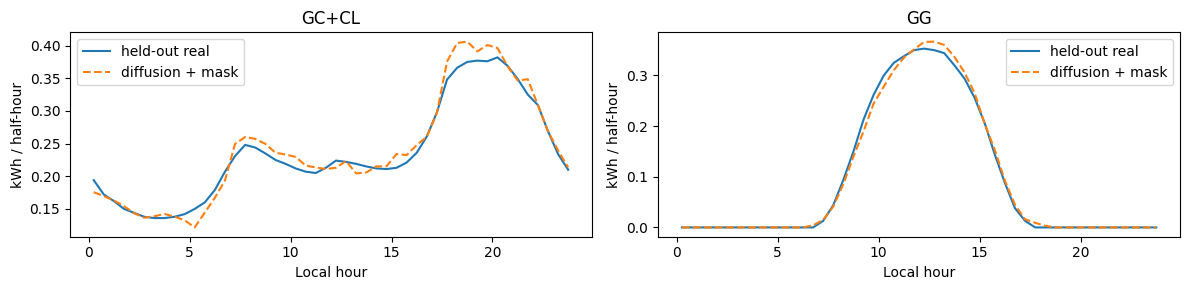

In [14]:
with np.load(SAMPLE_DIR/f'{MASKED_ARM}_seed1_test.npz',allow_pickle=False) as z:
    synthetic,indices=z['x'],z['idx']
real=DATA['x'][indices]
for channel,label in enumerate(('GC+CL','GG')):
    real_peak=real[:,channel].max(axis=1)
    fake_peak=synthetic[:,channel].max(axis=1)
    print(label,'interval peak percentiles real / generated:',
          np.quantile(real_peak,[.50,.95,.99]).round(3),
          np.quantile(fake_peak,[.50,.95,.99]).round(3),
          '| maximum generated:',round(float(fake_peak.max()),3))
fig,axes=plt.subplots(1,2,figsize=(12,3))
clock=np.arange(48)/2+0.25
for channel,label in enumerate(('GC+CL','GG')):
    axes[channel].plot(clock,np.median(real[:,channel],axis=0),label='held-out real')
    axes[channel].plot(clock,np.median(synthetic[:,channel],axis=0),label='diffusion + mask',ls='--')
    axes[channel].set(xlabel='Local hour',ylabel='kWh / half-hour',title=label)
    axes[channel].legend()
plt.tight_layout();plt.show()


### Decision record

Compare the **three paired seeds** and the peak/utility tradeoffs before declaring an improved method. The held-out test set is the same for all runs, so repeat seeds are **not** independent household samples. Report the selected mask arm, daily and peak metrics, real-trained utility reference, attack limitations, and any departures from the fixed config. Keep all internal `idx` files and the prepared household data out of public releases.
